In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
import powerlaw

In [3]:
# read in the 48hr average data produced by 02__create_48hr_averages.ipynb
open_path = "../output/data/48hr_averages/open_avg48hrs.pkl"
curfew_path = "../output/data/48hr_averages/curfew_avg48hrs.pkl"

opening = pd.read_pickle(open_path)
curfew = pd.read_pickle(curfew_path)

In [4]:
# Saving plots as pdf, png and svg
FIGURE_DIR = "../output/figures/descriptives"
os.makedirs(FIGURE_DIR, exist_ok=True)

def save_figure(filename_stem, directory=FIGURE_DIR):
    """Save the figure as pdf, png and svg."""
    for ext in ["pdf", "png", "svg"]:
        plt.savefig(f"{directory}/{filename_stem}.{ext}", dpi=300, bbox_inches="tight")

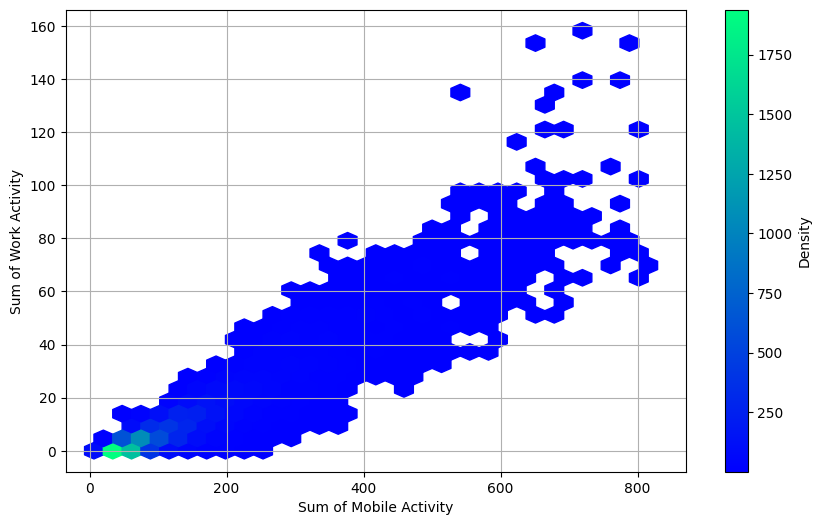

In [7]:
# create a scatterplot with x axis sum of traffic, y axis sum of work per hex

#filter to hour with most workers, to keep one count per day
opening_12am = opening[opening['hour_reordered'] == 12]

# Group by 'raster_id' and sum the 'traffic' and 'loc_work_once' columns
grouped_df = opening_12am.groupby('raster_id').agg(
    traffic=('traffic', 'sum'),
    loc_work_once=('loc_work_weekly', lambda x: x.sum(min_count=1))
).reset_index()
grouped_df = grouped_df.dropna(subset=['loc_work_once'])

plt.figure(figsize=(10, 6))
hb = plt.hexbin(grouped_df['traffic'], grouped_df['loc_work_once'], gridsize=30, cmap='winter', mincnt=1)
plt.colorbar(hb, label='Density')
plt.xlabel('Sum of Mobile Activity')
plt.ylabel('Sum of Work Activity')
#plt.title('Hexbin plot of Sum of Traffic vs Sum of Work per Raster_ID for 2 open months')
plt.grid(True)
save_figure("open_traffic_vs_work_hexbin")
plt.show()

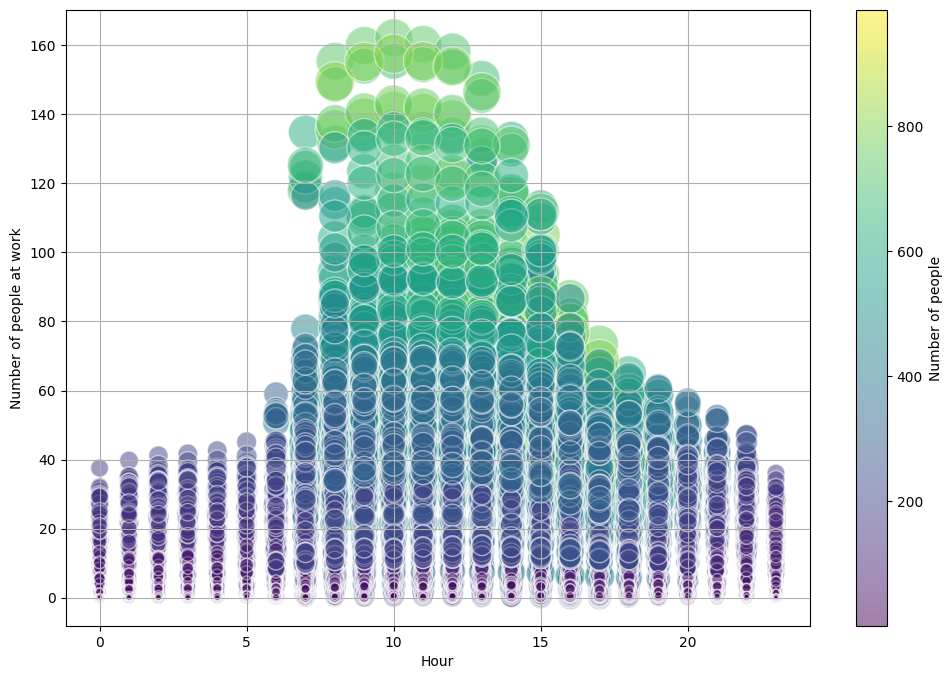

In [8]:
# Filter to the weekday half of the 48hr sequence (hour_reordered 0-23)
opening_weekday = opening[opening['hour_reordered'] < 24]

# Create the bubble plot
plt.figure(figsize=(12, 8))
plt.scatter(
    opening_weekday['hour_reordered'],  
    opening_weekday['loc_work_weekly'],   
    s=opening_weekday['traffic'],       # Bubble size: traffic
    alpha=0.5,                          
    edgecolors='w',                     
    cmap='viridis',                    
    c=opening_weekday['traffic']        # Color based on traffic values
)

plt.xlabel('Hour')
plt.ylabel('Number of people at work')
#plt.title('Bubble Plot of Work Activity vs Hour with Traffic as Bubble Size')
plt.colorbar(label='Number of people')
plt.grid(True)
save_figure("open_work_hour_bubble")
plt.show()

# Power law distribution

In [9]:
def fit_power_laws_by_hour(df, value_col):
    """For each weekday hour (0-23), drop NA/0 values and fit a power law.
    Returns a list of 24 powerlaw.Fit objects, indexed by hour."""
    fits = []
    weekday_df = df[df['hour_reordered'] < 24]
    for hour in range(24):
        hour_data = weekday_df.loc[weekday_df['hour_reordered'] == hour, value_col]
        hour_data = hour_data.dropna()
        hour_data = hour_data[hour_data > 0]
        fits.append(powerlaw.Fit(hour_data))
    return fits

In [10]:
# Fit power laws for home and work presence, weekday hours only, excluding raster_ids that
# are never a home / never a workplace
home_fits = fit_power_laws_by_hour(opening, 'loc_home_weekly')
work_fits = fit_power_laws_by_hour(opening, 'loc_work_weekly')

Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Calculating best min

In [11]:
# Retrieve the slopes for each hour from the fits
home_slopes = {hour: fit.alpha for hour, fit in enumerate(home_fits)}
work_slopes = {hour: fit.alpha for hour, fit in enumerate(work_fits)}

home_slopes, work_slopes

({0: 12.508260652654611,
  1: 13.071514827916301,
  2: 13.440017944258338,
  3: 13.101251686409679,
  4: 12.54095625413187,
  5: 12.889972610025179,
  6: 13.507992744054368,
  7: 15.293952357969827,
  8: 14.744373934864164,
  9: 14.935905813607864,
  10: 15.533191652007064,
  11: 14.737696010495496,
  12: 13.525641438891002,
  13: 14.092171973060115,
  14: 14.431647486269874,
  15: 14.632265137129858,
  16: 14.031139709332397,
  17: 14.566150445252731,
  18: 14.266612136807634,
  19: 13.981918879017906,
  20: 14.536665606249706,
  21: 13.747989469527337,
  22: 14.288704919165555,
  23: 2.4723134437033027},
 {0: 22.606142945033213,
  1: 10.80959748899164,
  2: 13.09651627657744,
  3: 12.804510203608702,
  4: 12.443272816691858,
  5: 2.260658487385198,
  6: 6.208257193667601,
  7: 6.474279197714803,
  8: 6.058604276834502,
  9: 6.536817138367368,
  10: 6.595758685721695,
  11: 6.734945702145394,
  12: 6.9100872567340454,
  13: 6.845268949189621,
  14: 7.383836258622358,
  15: 8.194731004

In [12]:
# Colour-code weekday hours into Night / Workday / Evening groups
HOUR_GROUP_COLORS = {
    '#fee8c8': [23, 0, 1, 2, 3, 4, 5, 6, 7],
    '#fc8d59': [8, 9, 10, 11, 12, 13, 14, 15, 16],
    '#b30000': [17, 18, 19, 20, 21, 22],
}
HOUR_GROUP_LABELS = {
    '#fee8c8': 'Night',
    '#fc8d59': 'Workday',
    '#b30000': 'Evening',
}

def plot_power_law_fits(fits, title, filename_stem):
    """Plot the 24 weekday-hour power law fits, colored by hour-of-day group, with a
    labeled colorbar, and save the figure (pdf/png/svg)."""
    fig, ax = plt.subplots(figsize=(10, 6))

    for fit, hour in zip(fits, range(24)):
        for color, hours in HOUR_GROUP_COLORS.items():
            if hour in hours:
                color_key = color
                break
        else:
            color_key = '#b30000'  # Default color for other hours
        fit.power_law.plot_pdf(color=color_key, linestyle='-', ax=ax, label='Power Law Fit')

    ax.set_xlabel('Value')
    ax.set_ylabel('Probability Density')
    ax.set_title(title)
    ax.grid(True)

    custom_colors = list(HOUR_GROUP_COLORS.keys())
    custom_cmap = ListedColormap(custom_colors)

    cax = fig.add_axes([0.92, 0.1, 0.02, 0.8])  # [left, bottom, width, height]
    cb = plt.colorbar(plt.cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(custom_colors) - 1)), cax=cax)
    cb.set_label('Hour Group')
    cb.set_ticks(range(len(custom_colors)))
    cb.set_ticklabels([HOUR_GROUP_LABELS[c] for c in custom_colors])

    save_figure(filename_stem)
    plt.show()

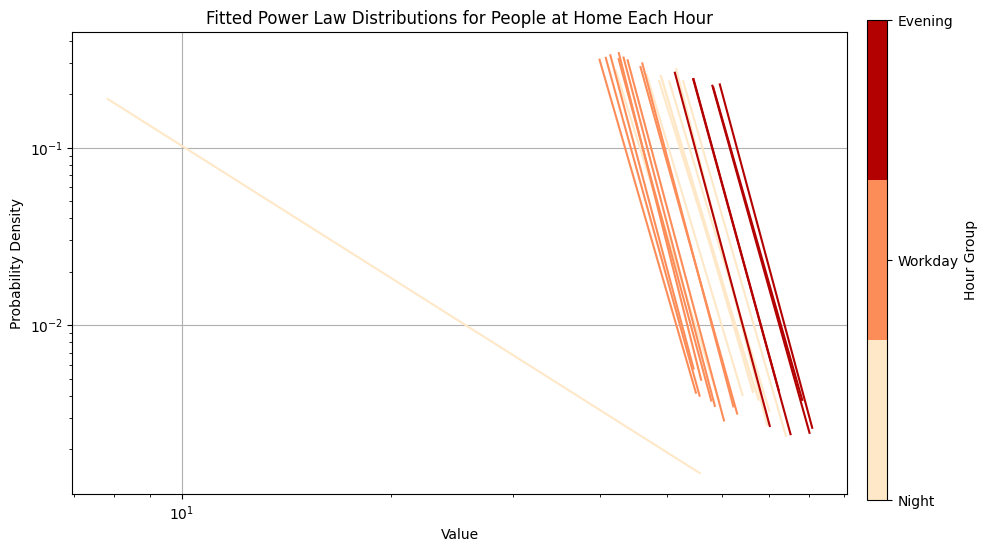

In [13]:
plot_power_law_fits(
    home_fits,
    'Fitted Power Law Distributions for People at Home Each Hour',
    'open_home_powerlaw'
)

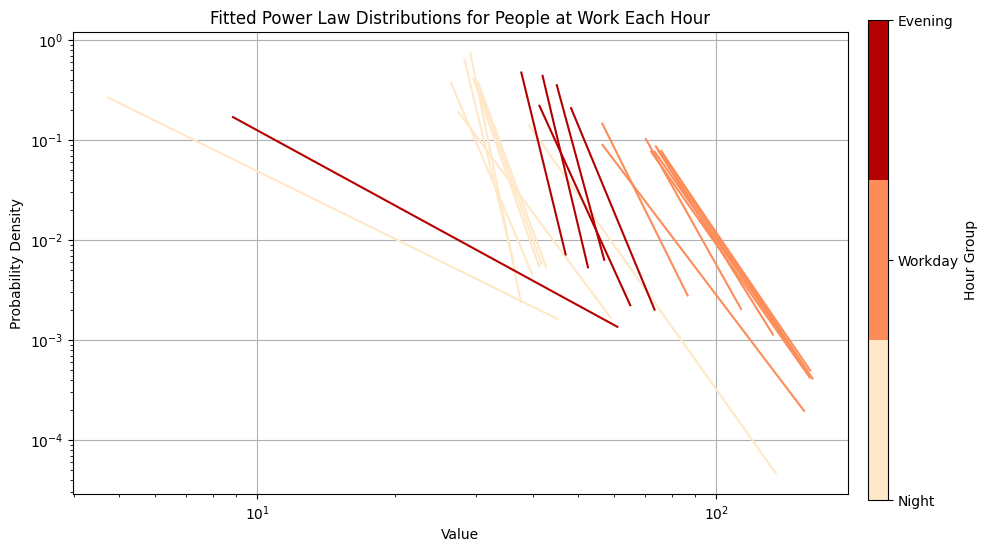

In [14]:
plot_power_law_fits(
    work_fits,
    'Fitted Power Law Distributions for People at Work Each Hour',
    'open_work_powerlaw'
)

# Compare curfew and open times

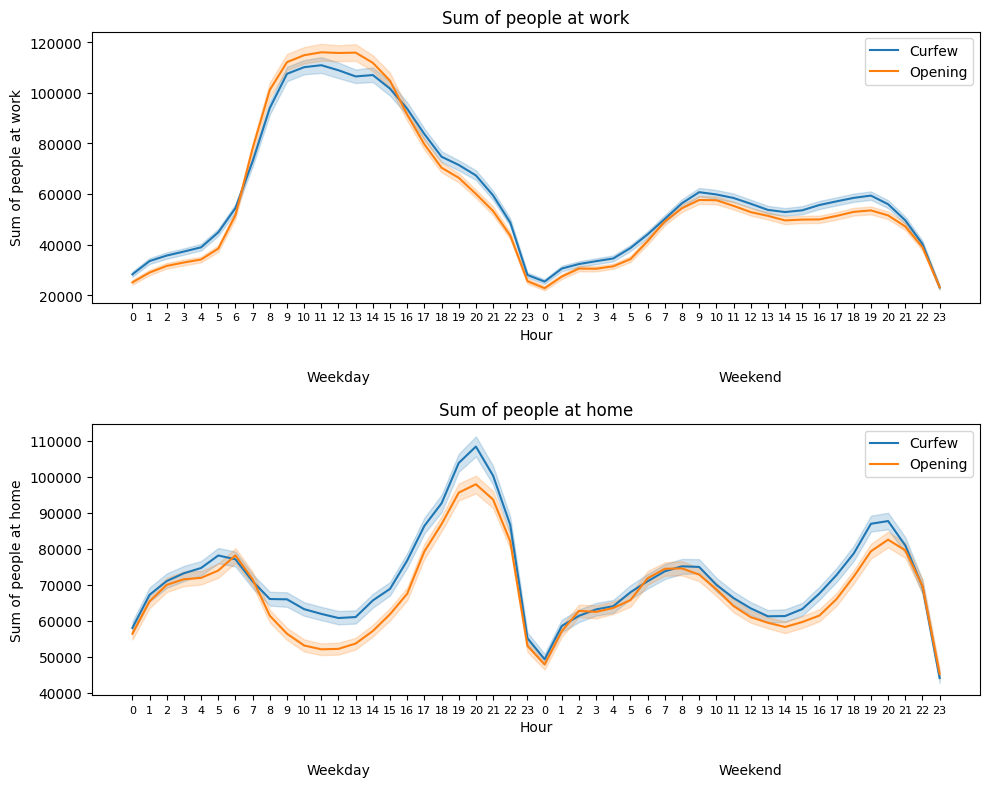

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Plot sum of loc_work for curfew and opening in the first subplot
sns.lineplot(x='hour_reordered', y='loc_work_weekly', data=curfew, estimator=np.nansum, ax=axes[0], label='Curfew')
sns.lineplot(x='hour_reordered', y='loc_work_weekly', data=opening, estimator=np.nansum, ax=axes[0], label='Opening')

axes[0].set_title('Sum of people at work')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Sum of people at work')
axes[0].legend()

# Plot sum of loc_home for curfew and opening in the second subplot
sns.lineplot(x='hour_reordered', y='loc_home_weekly', data=curfew, estimator=np.nansum, ax=axes[1], label='Curfew')
sns.lineplot(x='hour_reordered', y='loc_home_weekly', data=opening, estimator=np.nansum, ax=axes[1], label='Opening')

axes[1].set_title('Sum of people at home')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Sum of people at home')
axes[1].legend()

# Adjust xticks and add Weekday/Weekend labels for both subplots
xtick_labels = list(range(24)) + list(range(24))

for ax in axes:
    ax.set_xticks(list(range(48)))
    ax.set_xticklabels(xtick_labels, fontsize=8)

    y_min, y_max = ax.get_ylim()
    y_offset = y_min - (y_max - y_min) * 0.25
    ax.text(12, y_offset, 'Weekday', ha='center', va='top', fontsize=10, clip_on=False)
    ax.text(36, y_offset, 'Weekend', ha='center', va='top', fontsize=10, clip_on=False)


plt.tight_layout()
save_figure("curfew_vs_open_work_home_sum")
plt.show()